#### Import python libraries

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import random
import cv2


##### Set Display Options for pandas

In [3]:
pd.set_option('display.max_colwidth', None)

##### Let us get all the video action labels

In [4]:
all_train_paths = []
all_train_labels = []
training_dataset_path = '../../Data/videos/train'
for label in sorted(os.listdir(training_dataset_path)):
    for fname in os.listdir(f"{training_dataset_path}/{label}"):
        all_train_paths.append(f"{training_dataset_path}/{label}/{fname}")
        all_train_labels.append(label)

print(f"All Train paths: {all_train_paths}")
print(f"All Train Labels: {all_train_labels}")

All Train paths: ['../../Data/videos/train/cooking/vid_01 - Copy (10) - Copy.mp4', '../../Data/videos/train/cooking/vid_01 - Copy (10).mp4', '../../Data/videos/train/cooking/vid_01 - Copy (11) - Copy.mp4', '../../Data/videos/train/cooking/vid_01 - Copy (11).mp4', '../../Data/videos/train/cooking/vid_01 - Copy (12) - Copy.mp4', '../../Data/videos/train/cooking/vid_01 - Copy (12).mp4', '../../Data/videos/train/cooking/vid_01 - Copy (13) - Copy.mp4', '../../Data/videos/train/cooking/vid_01 - Copy (13).mp4', '../../Data/videos/train/cooking/vid_01 - Copy (14) - Copy.mp4', '../../Data/videos/train/cooking/vid_01 - Copy (14).mp4', '../../Data/videos/train/cooking/vid_01 - Copy (15) - Copy.mp4', '../../Data/videos/train/cooking/vid_01 - Copy (15).mp4', '../../Data/videos/train/cooking/vid_01 - Copy (16) - Copy.mp4', '../../Data/videos/train/cooking/vid_01 - Copy (16).mp4', '../../Data/videos/train/cooking/vid_01 - Copy (17) - Copy.mp4', '../../Data/videos/train/cooking/vid_01 - Copy (17).mp4'

##### A Dataframe Just to View the training data.

In [5]:
training_data_paths_dataframe = pd.DataFrame({
    "file_path": all_train_paths,
    "Label": all_train_labels
})

training_data_paths_dataframe

,file_path,Label
0,../../Data/videos/train/cooking/vid_01 - Copy (10) - Copy.mp4,cooking
1,../../Data/videos/train/cooking/vid_01 - Copy (10).mp4,cooking
2,../../Data/videos/train/cooking/vid_01 - Copy (11) - Copy.mp4,cooking
3,../../Data/videos/train/cooking/vid_01 - Copy (11).mp4,cooking
4,../../Data/videos/train/cooking/vid_01 - Copy (12) - Copy.mp4,cooking
...,...,...
795,../../Data/videos/train/washing_dishes/vid_01 - Copy (9) - Copy.mp4,washing_dishes
796,../../Data/videos/train/washing_dishes/vid_01 - Copy (9).mp4,washing_dishes
797,../../Data/videos/train/washing_dishes/vid_01 - Copy - Copy.mp4,washing_dishes
798,../../Data/videos/train/washing_dishes/vid_01 - Copy.mp4,washing_dishes


##### Encode Labels

In [6]:
le = LabelEncoder()
encoded_labels = le.fit_transform(all_train_labels)
encoded_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3,

##### Now Let us split our Dataset into train, test, and val

In [7]:
# The First Split - Split into train and test data subsets
X_original_train, X_test, y_original_train, y_test = train_test_split(
    all_train_paths, encoded_labels, test_size=0.10, stratify=encoded_labels, random_state=42
)

In [8]:
# The second Split - Split the previous split-training dataset into train and validation data subsets
# I took 90% of the remaining X_original_train dataset and split it again - I delegated 15% of this as validation
X_train, X_val, y_train, y_val = train_test_split(
    X_original_train, y_original_train, test_size=0.15, stratify=y_original_train, random_state=42
)

##### View the Data Split Below

In [9]:
total_number_of_data_points = len(all_train_paths)
total_number_of_train_data_points = len(X_train)
total_number_of_test_data_points = len(X_test)
total_number_of_validation_data_points = len(X_val)


data_counts_summarized = pd.DataFrame({
    'label': ["Number of Train Data Points", "Number of Test Data Points",  "Number of Validation Data Points"],
    'count': [total_number_of_train_data_points, total_number_of_test_data_points, total_number_of_validation_data_points]
})

data_counts_summarized

,label,count
0,Number of Train Data Points,612
1,Number of Test Data Points,80
2,Number of Validation Data Points,108


([<matplotlib.patches.Wedge at 0x1ee25bf4050>,
 [Text(-0.8076150608937801, -0.8875572733167906, 'Number of Train Data Points'),
  Text(1.0095299392023767, 0.4368630241323314, 'Number of Test Data Points'),
  Text(0.45266562901421503, 1.0025436790031472, 'Number of Validation Data Points')],
 [Text(-0.4711087855213717, -0.5177417427681278, '76.5%'),
  Text(0.5506526941103872, 0.23828892225399892, '10.0%'),
  Text(0.2469085249168445, 0.5468420067289893, '13.5%')])

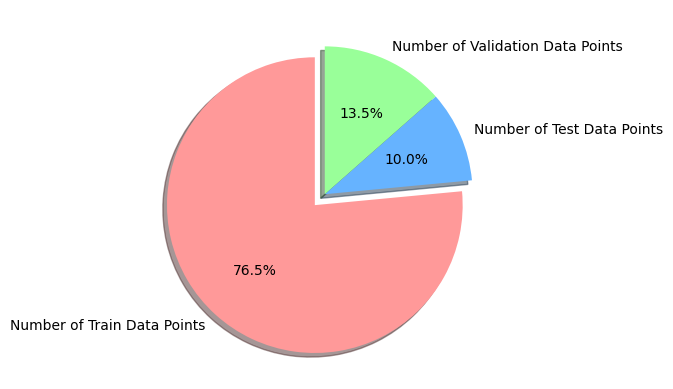

In [10]:
plt.pie(
    data_counts_summarized['count'],
    labels=data_counts_summarized['label'],
    autopct='%1.1f%%',       # Show percentages
    startangle=90,            # Rotate start angle
    explode=(0.1, 0, 0),     # "Explode" the first slice
    colors=['#ff9999','#66b3ff','#99ff99'],  # Custom colors
    shadow=True               # Add shadow
)

#### Let us do Feature extraction

In [11]:
NUMBER_OF_FRAMES = 16
FRAME_WIDTH = 112
FRAME_HEIGHT = 112
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32) # [R, G, B] - MobileNetV2 was pretrained on ImageNet using these RGB Channels
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32) # [R, G, B] - MobileNetV2 was pretrained on ImageNet using these RGB Channels

In [12]:
def extract_frames(video_path):
    captured_video = cv2.VideoCapture(video_path)
    total_number_of_frames = int(captured_video.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total Number of frames: {total_number_of_frames}")
    indices = np.linspace(0, total_number_of_frames - 1, NUMBER_OF_FRAMES, dtype=int) # Uniform Temporal Sampling
    frames = []
    for index in indices:
        captured_video.set(cv2.CAP_PROP_POS_FRAMES, int(index))
        ok, frame = captured_video.read() # read_succeeded?, actual_pixel_data as numpy array of shape (H, W, 3)
        
        if not ok:
            frame = frames[-1].copy() if frames else np.zeros((FRAME_HEIGHT, FRAME_WIDTH, 3), dtype=np.uint8) # repeat the last successfully read frame if reading of current frame failed [maintains 16 frames]. If very first frame fails AND frames list is still empty, then i create blank frame as a fallback
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (FRAME_WIDTH, FRAME_HEIGHT), interpolation=cv2.INTER_AREA) # resizes the frame from its original resolution down to 112×112.
            
        frames.append(frame)
    
    captured_video.release() # Close the video file and free the memory OpenCV allocated for the decoder.
    frames = np.stack(frames).astype(np.float32) / 255.0
    frames = (frames - IMAGENET_MEAN) / IMAGENET_STD
    return frames

                       

In [13]:
extract_frames('../../Data/videos/train/cooking/vid_01 - Copy (10) - Copy.mp4').shape

Total Number of frames: 266


(16, 112, 112, 3)

#### Build and Train the model

In [14]:
def make_dataset(paths, labels, augment=False, batch_size=8):

    def load(path, label):
        def _py(p):
            frames = extract_frames(p.numpy().decode())
            return frames.astype(np.float32)

        frames = tf.py_function(_py, [path], tf.float32)
        frames.set_shape([NUMBER_OF_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, 3])

        if augment:
            # Flip applied to all frames together — never frame-by-frame
            frames = tf.cond(tf.random.uniform(()) > 0.5,
                             lambda: tf.image.flip_left_right(frames),
                             lambda: frames)
            frames = tf.image.random_brightness(frames, 0.1)
            frames = tf.image.random_contrast(frames, 0.85, 1.15)
            frames = tf.clip_by_value(frames, 0.0, 1.0)

        return frames, tf.cast(label, tf.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if augment:
        ds = ds.shuffle(len(paths), reshuffle_each_iteration=True)
    return ds.map(load, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, y_train, augment=True)
val_ds   = make_dataset(X_val,   y_val,   augment=False)
test_ds  = make_dataset(X_test,  y_test,  augment=False)

#### Build and Train The Model

In [ ]:
NUM_CLASSES = len(le.classes_)

def build_model():
    backbone = keras.applications.MobileNetV2(
        input_shape=(FRAME_HEIGHT, FRAME_WIDTH, 3),
        include_top=False, weights='imagenet', pooling='avg'
    )
    backbone.trainable = False     # frozen in phase 1

    inp = keras.Input(shape=(NUMBER_OF_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, 3))
    x = layers.TimeDistributed(backbone)(inp)           # CNN on every frame
    x = layers.TimeDistributed(layers.Dropout(0.3))(x)
    x = layers.LSTM(256, return_sequences=True)(x)      # temporal patterns
    x = layers.LSTM(128)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return keras.Model(inp, out), backbone

model, backbone = build_model()
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Phase 1 — frozen backbone
model.fit(train_ds, validation_data=val_ds, epochs=20,
          callbacks=[
              keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
              keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3),
              keras.callbacks.ModelCheckpoint('best.keras', save_best_only=True),
          ])

# Phase 2 — unfreeze top CNN layers and fine-tune
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(1e-5),   # 10× lower LR
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=10)

# Evaluate
loss, acc = model.evaluate(test_ds)
print(f'Test accuracy: {acc:.3f}')
model.save('action_classifier.keras')
np.save('label_classes.npy', le.classes_)

C:\Users\User\AppData\Local\Temp\ipykernel_24688\3049775222.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = keras.applications.MobileNetV2(


Epoch 1/20
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
Total Number of frames: 266
 1/77 ━━━━━━━━━━━━━━━━━━━━ 1:42:59 81

KeyboardInterrupt: 

: 

##### Inference

In [ ]:
model   = tf.keras.models.load_model('action_classifier.keras')
classes = np.load('label_classes.npy', allow_pickle=True)

def classify_video(video_path, top_k=3):
    frames = extract_frames(video_path)             # same function as training
    frames = np.expand_dims(frames, 0)              # add batch dim → (1,16,112,112,3)
    probs  = model.predict(frames, verbose=0)[0]    # (NUM_CLASSES,)

    top_idx = np.argsort(probs)[::-1][:top_k]
    return [(classes[i], float(probs[i])) for i in top_idx]

# Example
results = classify_video('my_video.mp4')
for label, confidence in results:
    print(f'{label:<30s} {confidence*100:.1f}%')